# Frenar UN gen mantiene la microglia reparadora 8 semanas tras un derrame

Un derrame deja secuelas motoras durante meses. La microglia — las células inmunes del cerebro — intenta repararlo, pero entra en modo dañino a los pocos días. Un equipo de Yale probó si mantenerla en modo reparador con un fármaco mejora la recuperación en ratones. La diferencia se ve hasta **dos meses después**.

**Paper:** *Sustaining microglial reparative function enhances stroke recovery* · *Nature* (2026)
**DOI:** [10.1038/s41586-026-10480-0](https://doi.org/10.1038/s41586-026-10480-0)
**Video corto:** [Ver en YouTube](https://youtube.com/shorts/pCcqcN-FJxo)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-25-microglia-reparativa-stroke-zfp384/notebook.ipynb)


## Lo que midieron

El equipo identificó un gen, **Zfp384**, que se enciende en la microglia tras el derrame y la empuja al modo dañino. Diseñaron un oligonucleótido antisentido (ASO) — un fármaco que silencia ese gen específico — y lo inyectaron al cerebro 3 días después del derrame.

Compararon dos grupos de ratones:

- **ASO-control** (n=11): recibe un ASO inactivo
- **ASO-Zfp384** (n=10): recibe el ASO que silencia Zfp384

A cada ratón le aplicaron dos pruebas motoras estándar — **Corner test** (asimetría al girar) y **Cylinder test** (uso de patas al apoyarse) — desde 1 día antes del derrame hasta 56 días después. Score 0 = simétrico (sano); valores altos = mayor secuela motora.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TIMEPOINT_CLAVE = 14         # día post-stroke donde el efecto es más fuerte
COLOR_CONTROL = '#BBBBBB'    # gris — ratones que reciben ASO inactivo
COLOR_TRATADO = '#2563EB'    # azul CaM — ratones con Zfp384 silenciado
COLOR_ALERTA  = '#DC2626'    # rojo — para destacar el momento clave
FUENTE = 'Fuente: Du et al. (2026), Nature | Datos: Source Data Fig 6'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
SLUG = '2026-05-25-microglia-reparativa-stroke-zfp384'

# Cargar estilo CaM (local → fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Descargar datos si no existen (Colab)
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for fn in ['test_corner_aso.csv', 'test_cylinder_aso.csv', 'microglia_cell_interactions.csv']:
    local = f'datos/{fn}'
    if not os.path.exists(local):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{fn}', local)

corner = pd.read_csv('datos/test_corner_aso.csv')
cyl    = pd.read_csv('datos/test_cylinder_aso.csv')
inter  = pd.read_csv('datos/microglia_cell_interactions.csv')

print(f'Corner test: {len(corner)} mediciones · {corner["mouse_id"].nunique()} ratones · {corner["day"].nunique()} timepoints')
print(f'Cylinder test: {len(cyl)} mediciones')
print(f'Interacciones celulares: {len(inter)} tipos de celula')
print()
print('Grupos en corner test:')
print(corner.groupby('group')['mouse_id'].nunique())


Corner test: 210 mediciones · 11 ratones · 10 timepoints
Cylinder test: 210 mediciones
Interacciones celulares: 12 tipos de celula

Grupos en corner test:
group
ASO-Zfp384     10
ASO-control    11
Name: mouse_id, dtype: int64


## Aquí está.

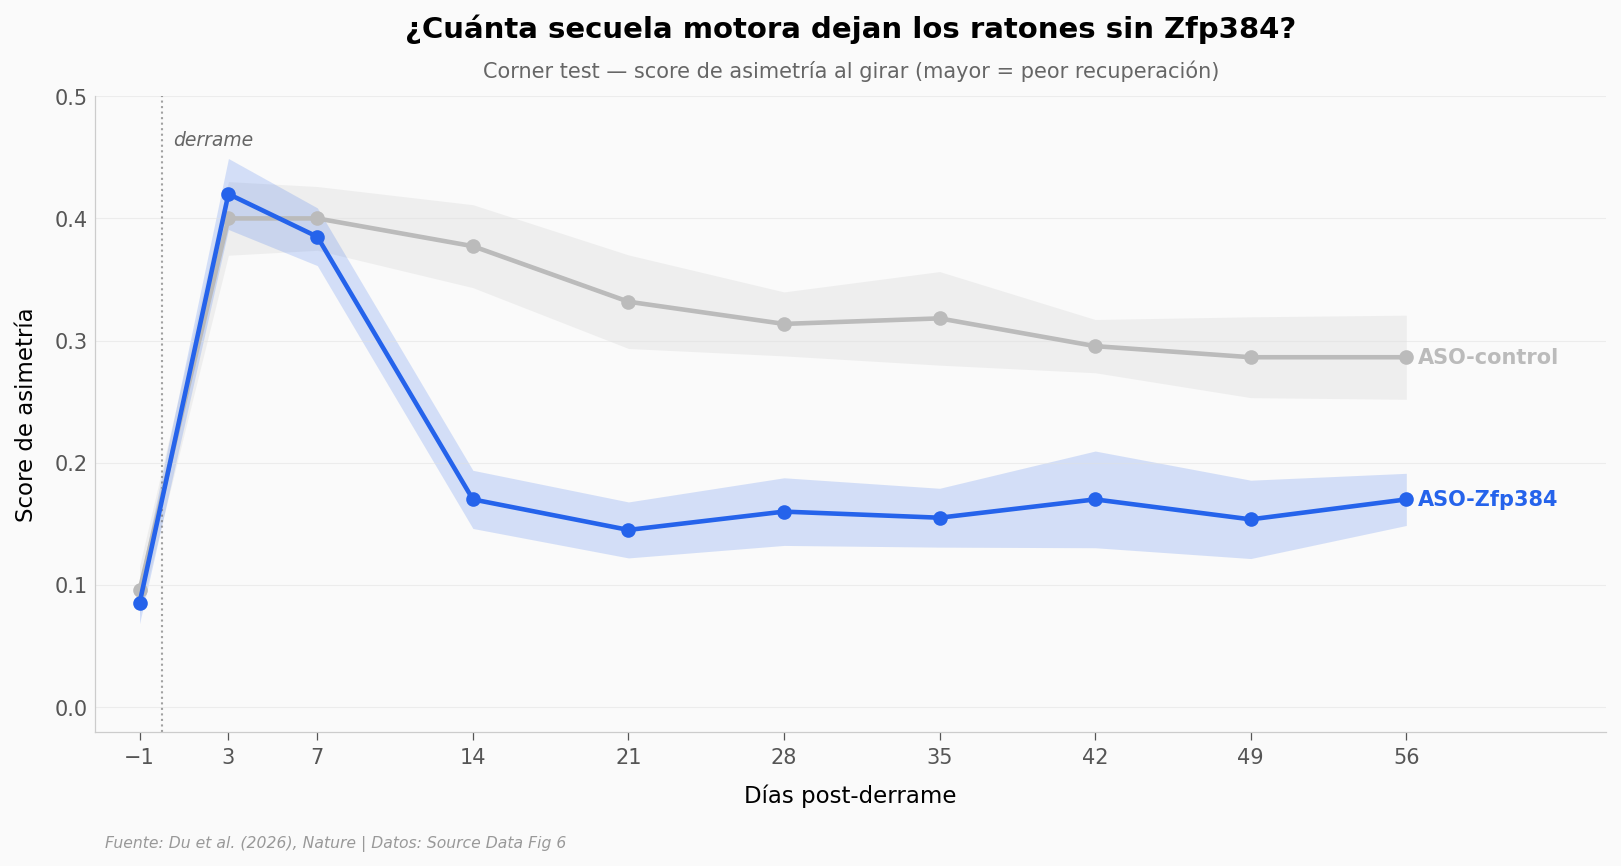

In [2]:
# Trayectoria temporal del Corner test — media ± SEM por grupo
fig, ax = plt.subplots(figsize=(13, 5.5))

agg = corner.groupby(['day', 'group'])['score'].agg(['mean', 'std', 'count']).reset_index()
agg['sem'] = agg['std'] / np.sqrt(agg['count'])

for group, color, label in [
    ('ASO-control',  COLOR_CONTROL, 'ASO-control (n=11)'),
    ('ASO-Zfp384',   COLOR_TRATADO, 'ASO-Zfp384 (n=10)'),
]:
    g = agg[agg['group'] == group].sort_values('day')
    ax.fill_between(g['day'], g['mean'] - g['sem'], g['mean'] + g['sem'],
                    color=color, alpha=0.18, linewidth=0)
    ax.plot(g['day'], g['mean'], color=color, linewidth=2.2,
            marker='o', markersize=6, label=label, zorder=5)

# Línea vertical del momento del stroke
ax.axvline(x=0, color='#666666', linewidth=1, linestyle=':', alpha=0.6)
ax.text(0.5, 0.46, 'derrame',
        fontsize=9, color='#666666', style='italic', ha='left')

# Inline labels (sin legend box)
ax.text(56.5, 0.286, 'ASO-control', fontsize=10, color=COLOR_CONTROL,
        fontweight='bold', va='center')
ax.text(56.5, 0.17, 'ASO-Zfp384', fontsize=10, color=COLOR_TRATADO,
        fontweight='bold', va='center')

ax.set_title('¿Cuánta secuela motora dejan los ratones sin Zfp384?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Corner test — score de asimetría al girar (mayor = peor recuperación)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('Días post-derrame', fontsize=11)
ax.set_ylabel('Score de asimetría', fontsize=11)
ax.set_xticks([-1, 3, 7, 14, 21, 28, 35, 42, 49, 56])
ax.set_xlim(-3, 65)
ax.set_ylim(-0.02, 0.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/corner_trayectoria.png', dpi=200, bbox_inches='tight')
plt.show()


## Lo que llama la atención

Los dos grupos arrancan iguales antes del derrame (día -1 ≈ 0). Tres días después, en ambos grupos sube fuerte la asimetría motora: el derrame es real y los afecta por igual.

La divergencia aparece a partir del día 7 y se consolida en el día 14: los ratones con Zfp384 silenciado bajan rápido, los control se quedan estancados arriba. La distancia entre las dos trayectorias **se mantiene hasta el día 56** — dos meses después de una sola intervención.

Eso es lo inusual del hallazgo: no es una mejoría temporal que se diluye. La microglia que se quedó en modo reparador siguió haciendo su trabajo semanas después de que el ASO ya se había eliminado del cerebro.


## ¿Se replica en una prueba independiente?

El Corner test mide asimetría al girar. Pero los ratones también usan las patas para apoyarse en las paredes del cilindro — eso es el **Cylinder test**, una prueba motora distinta hecha sobre los **mismos animales**.

Si el efecto de silenciar Zfp384 es real, debería aparecer también acá.


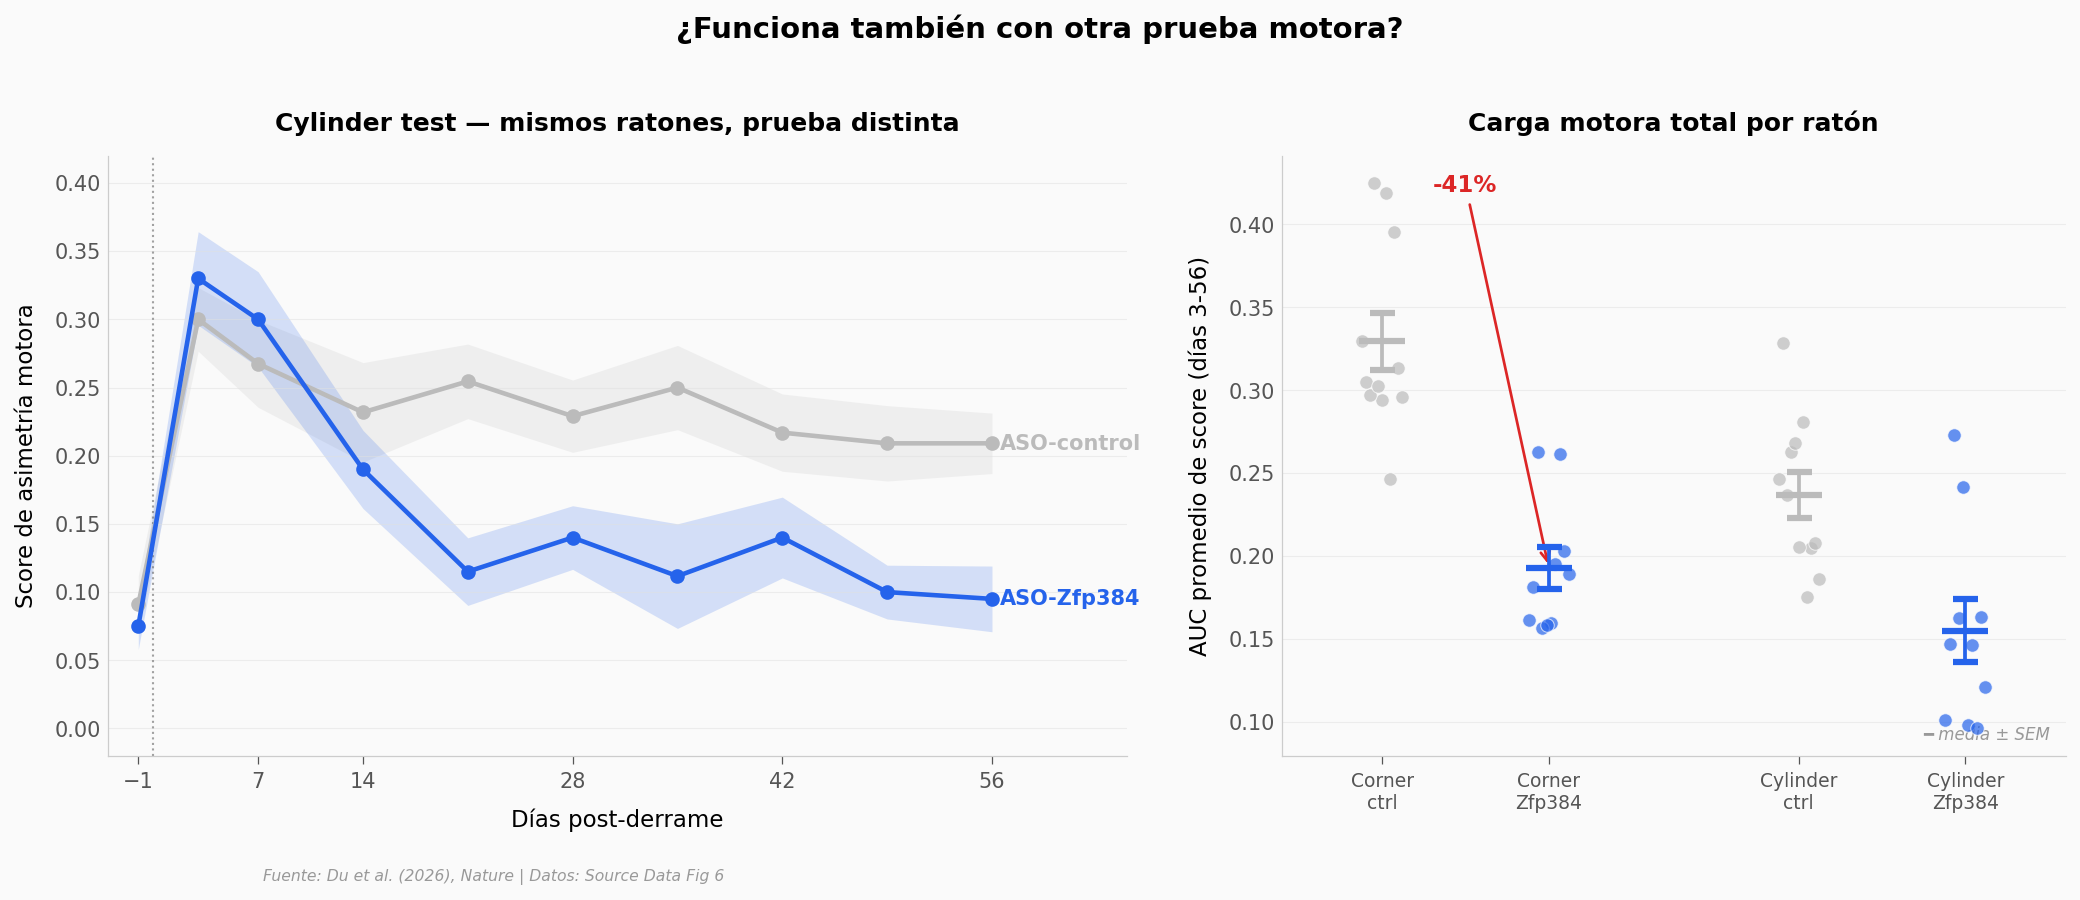

Corner AUC — ASO-control: 0.329, ASO-Zfp384: 0.193
  Reducción: 41.4%
  Mann-Whitney U=108.0, p=0.0002 · Cohen's d=2.74


In [3]:
# Cylinder test temporal + AUC por ratón en ambas pruebas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5),
                                gridspec_kw={'width_ratios': [1.3, 1]})

# Panel izquierdo: trayectoria Cylinder
agg_cyl = cyl.groupby(['day', 'group'])['score'].agg(['mean', 'std', 'count']).reset_index()
agg_cyl['sem'] = agg_cyl['std'] / np.sqrt(agg_cyl['count'])

for group, color, label in [
    ('ASO-control',  COLOR_CONTROL, 'ASO-control'),
    ('ASO-Zfp384',   COLOR_TRATADO, 'ASO-Zfp384'),
]:
    g = agg_cyl[agg_cyl['group'] == group].sort_values('day')
    ax1.fill_between(g['day'], g['mean'] - g['sem'], g['mean'] + g['sem'],
                     color=color, alpha=0.18, linewidth=0)
    ax1.plot(g['day'], g['mean'], color=color, linewidth=2.2,
             marker='o', markersize=6, zorder=5)

ax1.axvline(x=0, color='#666666', linewidth=1, linestyle=':', alpha=0.6)
ax1.text(56.5, 0.209, 'ASO-control', fontsize=10, color=COLOR_CONTROL,
         fontweight='bold', va='center')
ax1.text(56.5, 0.095, 'ASO-Zfp384', fontsize=10, color=COLOR_TRATADO,
         fontweight='bold', va='center')
ax1.set_title('Cylinder test — mismos ratones, prueba distinta',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Días post-derrame', fontsize=11)
ax1.set_ylabel('Score de asimetría motora', fontsize=11)
ax1.set_xticks([-1, 7, 14, 28, 42, 56])
ax1.set_xlim(-3, 65)
ax1.set_ylim(-0.02, 0.42)

# Panel derecho: AUC por ratón (área bajo la curva días 3-56)
def auc_per_mouse(df):
    rows = []
    for (group, mouse_id), sub in df.groupby(['group', 'mouse_id']):
        sub = sub[sub['day'] >= 3].sort_values('day')
        auc = np.trapezoid(sub['score'].values, sub['day'].values) / (sub['day'].max() - sub['day'].min())
        rows.append({'group': group, 'mouse_id': mouse_id, 'auc': auc})
    return pd.DataFrame(rows)

auc_corner = auc_per_mouse(corner)
auc_cyl    = auc_per_mouse(cyl)

np.random.seed(42)
positions = [0, 1, 2.5, 3.5]
data_panels = [
    ('Corner\nctrl', auc_corner[auc_corner['group']=='ASO-control']['auc'].values, COLOR_CONTROL),
    ('Corner\nZfp384', auc_corner[auc_corner['group']=='ASO-Zfp384']['auc'].values, COLOR_TRATADO),
    ('Cylinder\nctrl', auc_cyl[auc_cyl['group']=='ASO-control']['auc'].values, COLOR_CONTROL),
    ('Cylinder\nZfp384', auc_cyl[auc_cyl['group']=='ASO-Zfp384']['auc'].values, COLOR_TRATADO),
]

for i, (lbl, vals, color) in enumerate(data_panels):
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.12, positions[i] + 0.12, n)
    np.random.shuffle(x_strip)
    ax2.scatter(x_strip, vals, color=color, s=42, alpha=0.7,
                edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax2.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                 markersize=22, markeredgewidth=3,
                 capsize=6, capthick=1.5, zorder=6)

ax2.set_xticks(positions)
ax2.set_xticklabels([d[0] for d in data_panels], fontsize=9)
ax2.set_ylabel('AUC promedio de score (días 3-56)', fontsize=11)
ax2.set_title('Carga motora total por ratón',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_xlim(-0.6, 4.1)
ax2.text(0.98, 0.02, '━ media ± SEM', transform=ax2.transAxes,
         fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

# Anotar el delta del AUC corner
ctrl_corner_auc = auc_corner[auc_corner['group']=='ASO-control']['auc'].mean()
zfp_corner_auc = auc_corner[auc_corner['group']=='ASO-Zfp384']['auc'].mean()
delta_pct = (1 - zfp_corner_auc/ctrl_corner_auc) * 100
ax2.annotate(f'-{delta_pct:.0f}%',
             xy=(1, zfp_corner_auc), xytext=(0.5, 0.42),
             fontsize=11, fontweight='bold', color=COLOR_ALERTA,
             arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3),
             ha='center')

fig.suptitle('¿Funciona también con otra prueba motora?',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/cylinder_auc.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats
print(f'Corner AUC — ASO-control: {ctrl_corner_auc:.3f}, ASO-Zfp384: {zfp_corner_auc:.3f}')
print(f'  Reducción: {delta_pct:.1f}%')
ctrl_v = auc_corner[auc_corner['group']=='ASO-control']['auc'].values
zfp_v  = auc_corner[auc_corner['group']=='ASO-Zfp384']['auc'].values
u, p = stats.mannwhitneyu(ctrl_v, zfp_v, alternative='two-sided')
pooled_std = np.sqrt((ctrl_v.std(ddof=1)**2 + zfp_v.std(ddof=1)**2) / 2)
d = (ctrl_v.mean() - zfp_v.mean()) / pooled_std
print(f'  Mann-Whitney U={u:.1f}, p={p:.4f} · Cohen\'s d={d:.2f}')


## ¿Por qué la mejora se mantiene tanto tiempo?

La hipótesis del paper es que la microglia "rescatada" no actúa sola: empieza a hablar con otras células del tejido cerebral dañado. Para ponerlo a prueba, el equipo mapeó esas conversaciones moleculares — con qué tipos de células la microglia reparadora intercambia señales y con qué intensidad (usaron NicheNet y CellChat, dos herramientas estándar del campo).


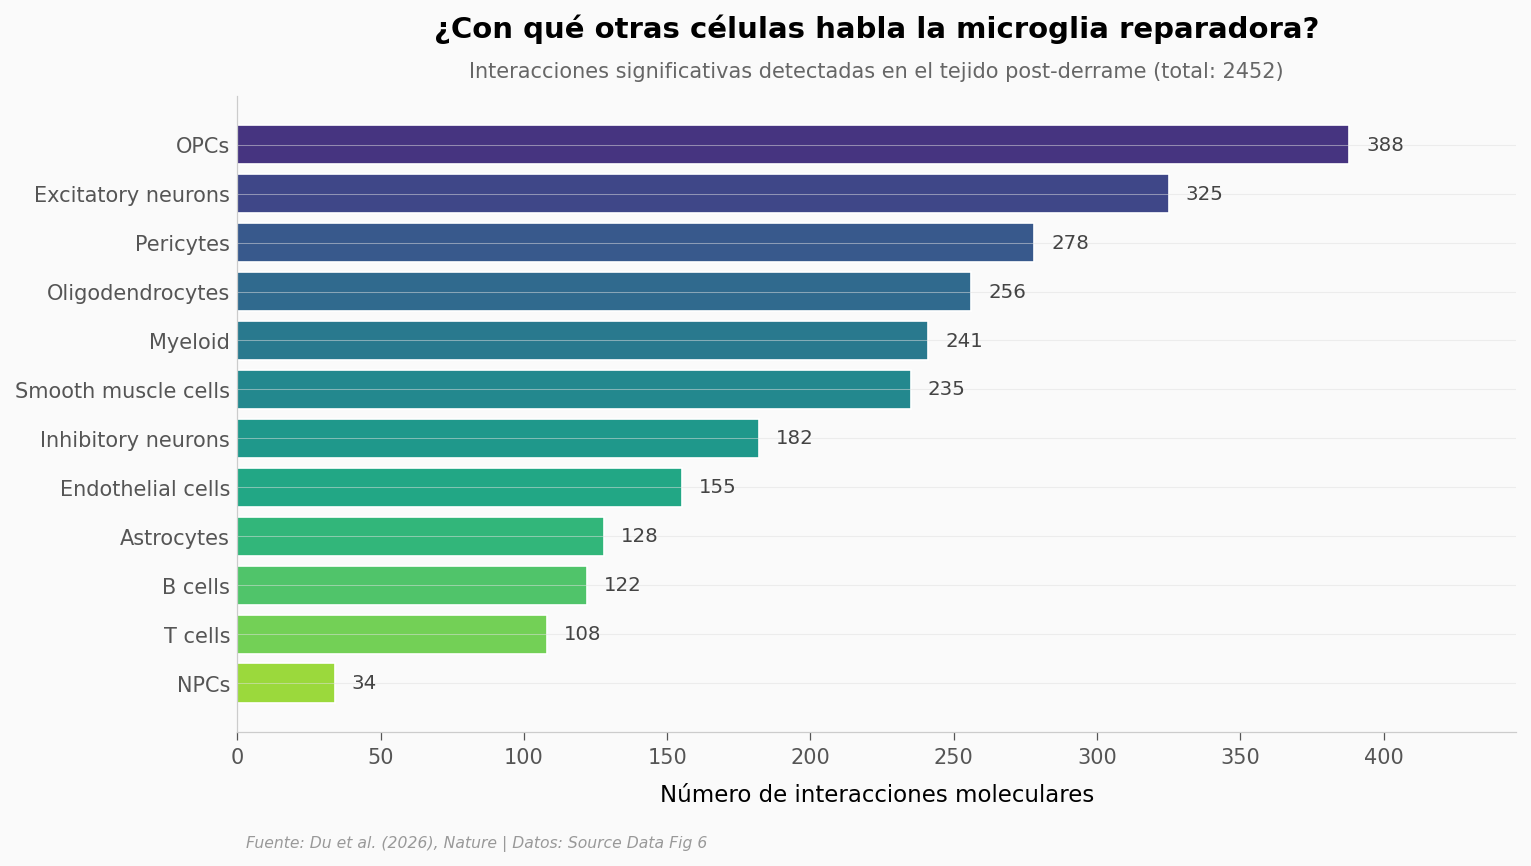

Total de tipos celulares: 12
Top 1: OPCs con 388 interacciones
Mediana: 208 interacciones


In [4]:
# Top 12 tipos celulares con los que interactua la microglia reparadora
fig, ax = plt.subplots(figsize=(11, 5.5))

inter_sorted = inter.sort_values('interaction_count', ascending=True)
total = inter_sorted['interaction_count'].sum()

# Colormap viridis_r — destaca los más altos en azul oscuro
colors = plt.cm.viridis_r(np.linspace(0.15, 0.85, len(inter_sorted)))

bars = ax.barh(inter_sorted['cell_type'], inter_sorted['interaction_count'],
               color=colors, edgecolor='white', linewidth=0.8)

# Anotar valor al final de cada barra
for bar, val in zip(bars, inter_sorted['interaction_count']):
    ax.text(val + 6, bar.get_y() + bar.get_height()/2,
            f'{int(val)}', va='center', fontsize=9.5, color='#444444')

ax.set_title('¿Con qué otras células habla la microglia reparadora?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Interacciones significativas detectadas en el tejido post-derrame (total: {total})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('Número de interacciones moleculares', fontsize=11)
ax.set_xlim(0, inter_sorted['interaction_count'].max() * 1.15)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cell_interactions.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Total de tipos celulares: {len(inter)}')
print(f'Top 1: {inter_sorted.iloc[-1]["cell_type"]} con {inter_sorted.iloc[-1]["interaction_count"]} interacciones')
print(f'Mediana: {int(inter["interaction_count"].median())} interacciones')


## ¿Qué tan grande es el efecto comparado con lo habitual?

En neurociencia, un Cohen's d de 0.5 ya se considera un efecto moderado; valores > 0.8 son grandes. Veamos cómo se ve el efecto del ASO-Zfp384 en cada día medido — y dónde queda frente a esa escala.


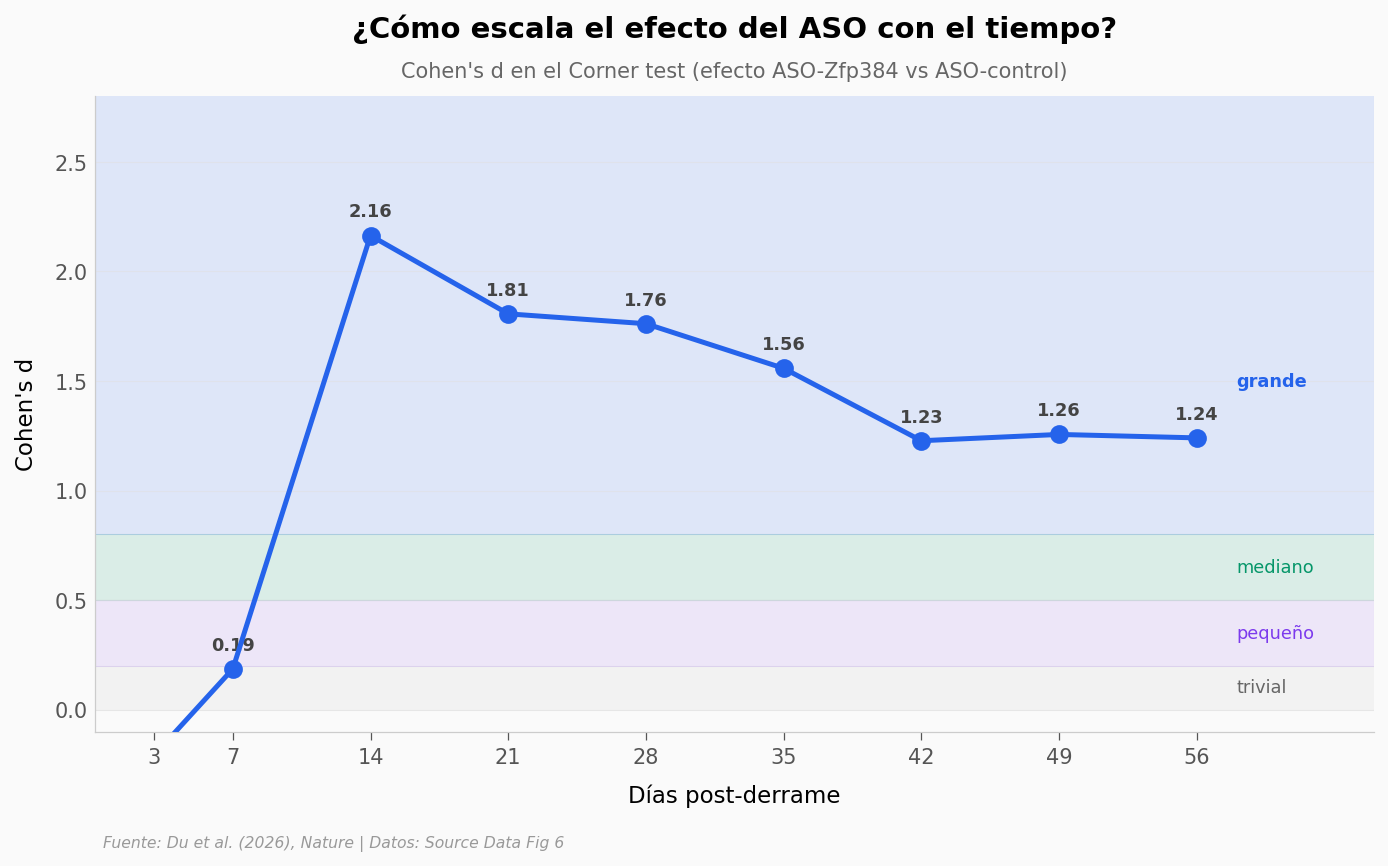

Cohen's d por día: D3=-0.21, D7=0.19, D14=2.16, D21=1.81, D28=1.76, D35=1.56, D42=1.23, D49=1.26, D56=1.24
Máximo: D14 con d=2.16


In [5]:
# Cohen's d por timepoint — Corner test
fig, ax = plt.subplots(figsize=(11, 5.5))

# Calcular Cohen's d por dia para corner test
ds = []
days = sorted([d for d in corner['day'].unique() if d > 0])
for day in days:
    ctrl_v = corner[(corner['day']==day) & (corner['group']=='ASO-control')]['score'].values
    zfp_v  = corner[(corner['day']==day) & (corner['group']=='ASO-Zfp384')]['score'].values
    pooled_std = np.sqrt((ctrl_v.std(ddof=1)**2 + zfp_v.std(ddof=1)**2) / 2)
    d = (ctrl_v.mean() - zfp_v.mean()) / pooled_std if pooled_std > 0 else 0
    ds.append(d)

# Bandas de referencia (interpretación estándar)
ax.axhspan(0,   0.2, alpha=0.08, color='#999999')
ax.axhspan(0.2, 0.5, alpha=0.10, color='#7C3AED')
ax.axhspan(0.5, 0.8, alpha=0.13, color='#059669')
ax.axhspan(0.8, 3.0, alpha=0.13, color='#2563EB')

ax.text(58, 0.10, 'trivial',  fontsize=8.5, color='#666666', va='center')
ax.text(58, 0.35, 'pequeño',  fontsize=8.5, color='#7C3AED', va='center')
ax.text(58, 0.65, 'mediano',  fontsize=8.5, color='#059669', va='center')
ax.text(58, 1.50, 'grande',   fontsize=8.5, color='#2563EB', va='center', fontweight='bold')

ax.plot(days, ds, color=COLOR_TRATADO, linewidth=2.4, marker='o',
        markersize=8, zorder=5)
for day, d in zip(days, ds):
    ax.annotate(f'{d:.2f}', xy=(day, d), xytext=(0, 9),
                textcoords='offset points', ha='center', fontsize=8.5,
                color='#444444', fontweight='bold')

ax.set_title('¿Cómo escala el efecto del ASO con el tiempo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        "Cohen's d en el Corner test (efecto ASO-Zfp384 vs ASO-control)",
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('Días post-derrame', fontsize=11)
ax.set_ylabel("Cohen's d", fontsize=11)
ax.set_xticks(days)
ax.set_xlim(0, 65)
ax.set_ylim(-0.1, 2.8)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cohens_d_temporal.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Cohen's d por día: " + ", ".join(f'D{day}={d:.2f}' for day, d in zip(days, ds)))
print(f"Máximo: D{days[np.argmax(ds)]} con d={max(ds):.2f}")


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El ASO-Zfp384 reduce la asimetría motora en el Corner test al día 14 | ✅ | Diferencia 54.9% (ctrl 0.377 vs Zfp 0.170), Cohen's d=2.14, Mann-Whitney p=0.0006 (n=11 vs 10) |
| El efecto se mantiene a los 56 días post-derrame | ✅ | Corner D56: ctrl 0.286 vs Zfp 0.170, d=1.22, p=0.0154 |
| El efecto se replica en una prueba motora independiente (Cylinder) | ✅ | Aparece desde D21 (d=1.65, p=0.0034) y se mantiene en D28, D35, D49 y D56 (d=1.52, p=0.0061). En D7 y D14 aún no es significativo — la divergencia entre tests aparece más tarde que en Corner, pero se consolida |
| La microglia reparadora interactúa con múltiples tipos celulares | ✅ | 12 tipos celulares detectados, OPCs el top con 388 interacciones, mediana 208 |
| Los OPCs son el principal socio de la microglia reparadora | ✅ | OPCs lidera con 388, seguido de neuronas excitatorias (325) y pericitos (278) |

> **Limitaciones:**
> - Estudio en ratones — la confirmación humana en el paper es observacional (microglia post-mortem de cerebros humanos en Fig 6), no terapéutica.
> - n pequeño por grupo (11 vs 10): el test no paramétrico (Mann-Whitney) ya lo refleja.
> - No conocemos los datos crudos de los Fig 1-5 (single-cell, scoring de microglia) — solo replicamos el experimento de validación funcional (Fig 6).
> - El ASO se aplica 3 días después del derrame en condiciones controladas; trasladar la ventana terapéutica a humanos requiere más trabajo.


## Ahora tú

Tres preguntas para abrir con este dataset:

1. **¿Cuándo arranca la divergencia exactamente?** El efecto se nota en D14, pero ¿se podría detectar antes con más sensibilidad? Prueba calcular el día más temprano donde el intervalo de confianza del 95% deja de solaparse entre los dos grupos.
2. **¿Hay ratones "no respondedores"?** Mira la distribución individual del AUC del grupo Zfp384. ¿Todos bajan? ¿Hay alguno que se quede como los control?
3. **¿La mejora en Corner predice la mejora en Cylinder ratón-por-ratón?** Si la microglia es la que repara, los mismos animales que mejoran en un test deberían mejorar en el otro. Prueba un scatter Corner-AUC vs Cylinder-AUC con su Spearman.


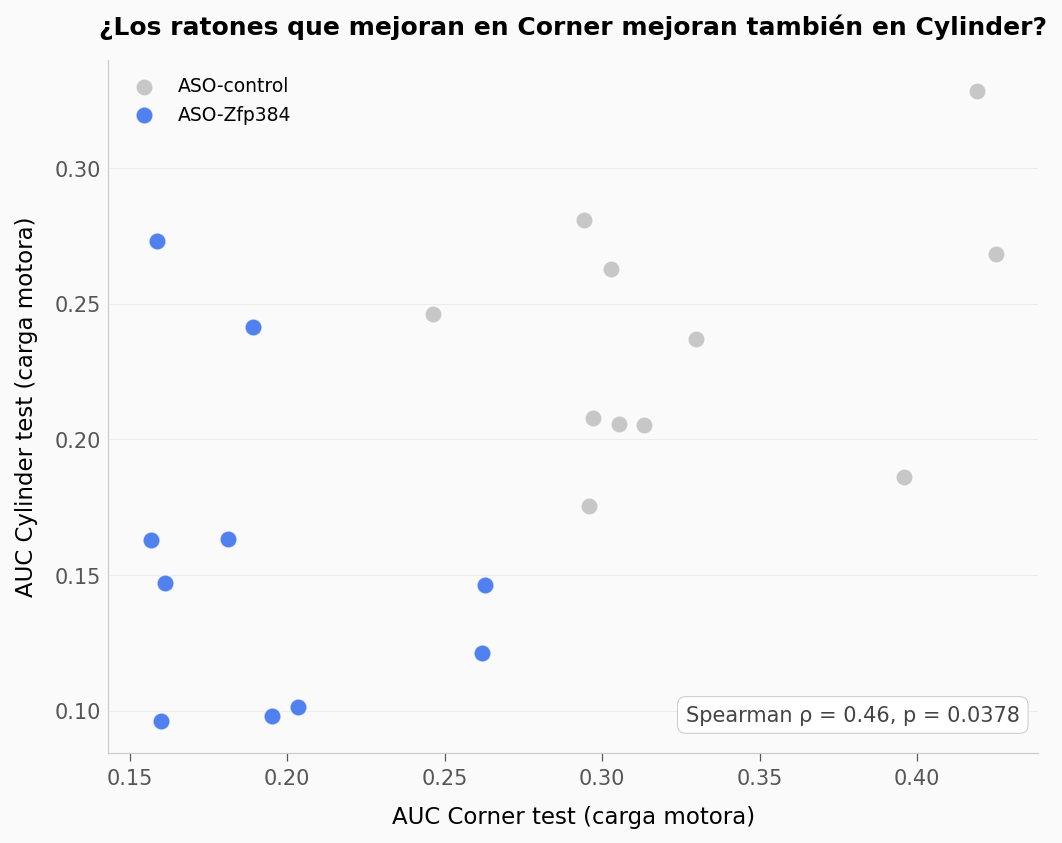

Correlación Spearman entre Corner y Cylinder AUC: ρ=0.456, p=0.0378
Interpretación: asociación débil ratón-por-ratón


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: ¿La mejora en un test predice la mejora en el otro?
fig, ax = plt.subplots(figsize=(8, 6))

merged = auc_corner.merge(auc_cyl, on=['group','mouse_id'], suffixes=('_corner','_cyl'))

for group, color, label in [
    ('ASO-control', COLOR_CONTROL, 'ASO-control'),
    ('ASO-Zfp384',  COLOR_TRATADO, 'ASO-Zfp384'),
]:
    g = merged[merged['group']==group]
    ax.scatter(g['auc_corner'], g['auc_cyl'], color=color, s=70, alpha=0.8,
               edgecolors='white', linewidths=0.8, label=label, zorder=5)

# Correlación Spearman (no parametrica)
rho, p = stats.spearmanr(merged['auc_corner'], merged['auc_cyl'])

ax.set_title('¿Los ratones que mejoran en Corner mejoran también en Cylinder?',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('AUC Corner test (carga motora)', fontsize=11)
ax.set_ylabel('AUC Cylinder test (carga motora)', fontsize=11)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.text(0.98, 0.04, f'Spearman ρ = {rho:.2f}, p = {p:.4f}',
        transform=ax.transAxes, fontsize=10, color='#444444',
        ha='right', va='bottom',
        bbox=dict(facecolor='white', edgecolor='#CCCCCC', boxstyle='round,pad=0.4'))

plt.savefig('figuras/cross_test_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Correlación Spearman entre Corner y Cylinder AUC: ρ={rho:.3f}, p={p:.4f}')
print(f'Interpretación: {"asociación moderada-fuerte" if abs(rho) > 0.5 else "asociación débil"} ratón-por-ratón')


---

## Fuentes

**Paper**: [Sustaining microglial reparative function enhances stroke recovery](https://doi.org/10.1038/s41586-026-10480-0)  
*Nature, 2026-05-13*

**Source Data del paper** (Supplementary Materials del mismo DOI):
- [Source Data for Fig 3 — Behavioral motor tests Corner/Cylinder (MOESM4)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10480-0/MediaObjects/41586_2026_10480_MOESM4_ESM.xlsx)
- [Source Data for Fig 4 — Microglia-cell interactions post-stroke (MOESM5)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10480-0/MediaObjects/41586_2026_10480_MOESM5_ESM.xlsx)

*12 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducible en Colab** o localmente con `pip install pandas matplotlib numpy scipy`.
**Licencia:** datos del paper bajo licencia editorial Nature · código del notebook bajo MIT (este repo).
**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
